### Notebook for test and demonstration of Projectiles and Simulation Loop

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

from mad.configs import EARTH_SETTINGS
from mad.objs import ProjectileConfig
from mad.objs import Planet, PlanetConfig
from mad.utils.logger import SourceLogger
from mad.utils.plotters import plot_2D_planet_with_points
import matplotlib.pyplot as plt

logger = SourceLogger()

Let's create a Planet object with parameter similar to Earth.
We can see that an object will need a speed between 7900 m/s 11000 m/s to be in orbit.

In [3]:
EARTH_SETTINGS["position"] = [0.0, 0.0]
earth = Planet(PlanetConfig(**EARTH_SETTINGS))

earth

Planet Earth at [0. 0. 0.]
Mass 5.97e+24 kg, Radius 6371.0 km.
Gravity at surface: 9.82 m/s^2
Orbital velocity: 7909.55 m/s
Escape velocity: 11185.79 m/s

In [4]:
# As an example, let's create a projectile with a mass of 10 kg. 
# A reference radius of 0.0 means there will be no drag applied
projectile_cfg = ProjectileConfig(
    **{
        "mass": 10.0,
        "name": "Rock",
        "ref_radius": 0.0,
    }
)

t = 0.0

# Let's create the projectile at a position of 1000 meters above the surface of the planet, and with a velocity of 1.2 times the orbital velocity of the planet.
# 
proj = projectile_cfg.create(position=[earth.radius + 1000, 0.0], velocity=[0, earth.orbital_velocity * 1.2], t=t)

# Let's check the initial velocity of the projectile. It should be enough for an orbital trajectory but not enough to escape the planet's gravity.
earth.orbital_velocity * 1.2

np.float64(9491.460551981754)

Every Object that can be interfaced with a simulation get a **.integrate()** method allowing to update their position and velocity acording to simulation dt and the interacting planet.

To call **.integrate()** on every object is enough to run the simulation.

In [5]:
dt = 1

# These arrays will store the time, position, and velocity of the projectile at each time step.
time_scale = [t]
pos, vel = [proj.position.copy()], [proj.velocity.copy()]

logger["Simulation"].info(f" Starting simulation at t={t:.2f} with dt={dt:.2f} sec")
while t < 20000:
    # We will update this object for every time step, and it will update its position and velocity based on the gravitational force of the planet.
    proj.integrate(dt, planet=earth)

    # This is only to store time, position and velocity for plotting later.
    time_scale.append(t)
    pos.append(proj.position.copy())
    vel.append(proj.velocity.copy())
    t += dt
    # We want to stop early if the projectile is no longer active, which means it has crashed into the planet.
    if not proj.active:
        break

logger["Simulation"].info(f" Simulation ended at t={t:.2f}")

16:18:35 | INFO     | Simulation   |  Starting simulation at t=0.00 with dt=1.00 sec
16:18:36 | INFO     | Simulation   |  Simulation ended at t=20000.00


In [6]:
# Getting speed and altitude for plotting
pos = np.asarray(pos)
vel = np.asarray(vel)

posx, posz = pos[:, 0], pos[:, 1]

altitude = np.linalg.norm(pos, axis=1) - earth.radius
velout = np.linalg.norm(vel, axis=1)

Plotting speed and altitude, we can see the projectile followed the expected trajectory: a non-circular orbit.

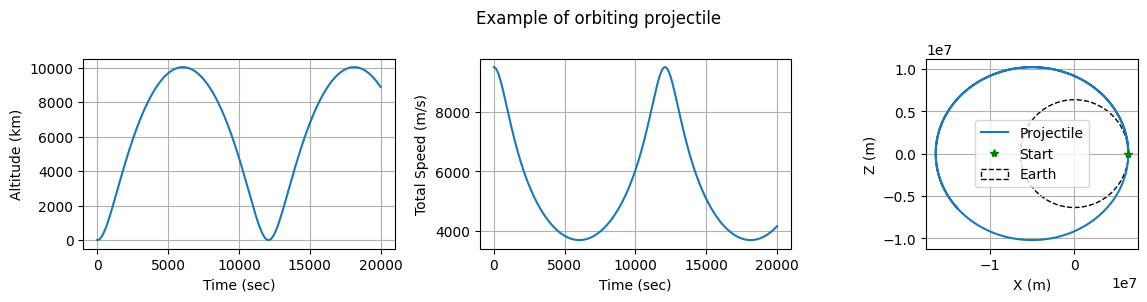

In [7]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(12, 3))
ax.flatten()

ax[0].plot(time_scale, altitude / 1000)
ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")
ax[0].grid()

ax[1].plot(time_scale, velout)
ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")
ax[1].grid()

ax[2].plot(posx, posz, label="Projectile")
ax[2].plot(posx[0], posz[0], "g*", label="Start")
ax[2].set_xlabel("X (m)")
ax[2].set_ylabel("Z (m)")
plot_2D_planet_with_points(planet = earth, ax=ax[2],)


fig.suptitle("Example of orbiting projectile")
fig.tight_layout(pad=0.8)

In [ ]:
other_earth = Planet(PlanetConfig(**EARTH_SETTINGS))
other_earth.position = np.array([-4.2e7, 0.0, 0.0])
other_earth.radius = 3e6
other_earth.name = "Other Planet"

t = 0.0
dt = 1.0
projectile_cfg = ProjectileConfig(
    mass=10.0,
    name="Rock",
    ref_radius=0.0,
)

proj2 = projectile_cfg.create(
    position=[earth.radius + 1000, 0.0],
    velocity=[0.0, earth.orbital_velocity * 1.2],
    t=0.0,
)

proj2.set_reference_planet(earth)
proj2.bind_environment(gravity_bodies={earth, other_earth})

In [45]:
# These arrays will store the time, position, and velocity of the projectile at each time step.
time_scale = [t]
pos, vel = [proj2.position.copy()], [proj2.velocity.copy()]

logger["Simulation"].info(f" Starting simulation at t={t:.2f} with dt={dt:.2f} sec")
while t < 30000:
    # We will update this object for every time step, and it will update its position and velocity based on the gravitational force of the planet.
    proj2.integrate(dt)

    # This is only to store time, position and velocity for plotting later.
    time_scale.append(t)
    pos.append(proj2.position.copy())
    vel.append(proj2.velocity.copy())
    t += dt
    # We want to stop early if the projectile is no longer active, which means it has crashed into the planet.
    if not proj2.active:
        break

logger["Simulation"].info(f" Simulation ended at t={t:.2f}")

16:26:35 | INFO     | Simulation   |  Starting simulation at t=0.00 with dt=1.00 sec
16:26:36 | INFO     | Projectile   | 0.00s - Rock landed on the ground!
16:26:36 | INFO     | Simulation   |  Simulation ended at t=21219.00


In [46]:
# Getting speed and altitude for plotting
pos = np.asarray(pos)
vel = np.asarray(vel)

posx, posz = pos[:, 0], pos[:, 1]

altitude = np.linalg.norm(pos, axis=1) - earth.radius
velout = np.linalg.norm(vel, axis=1)

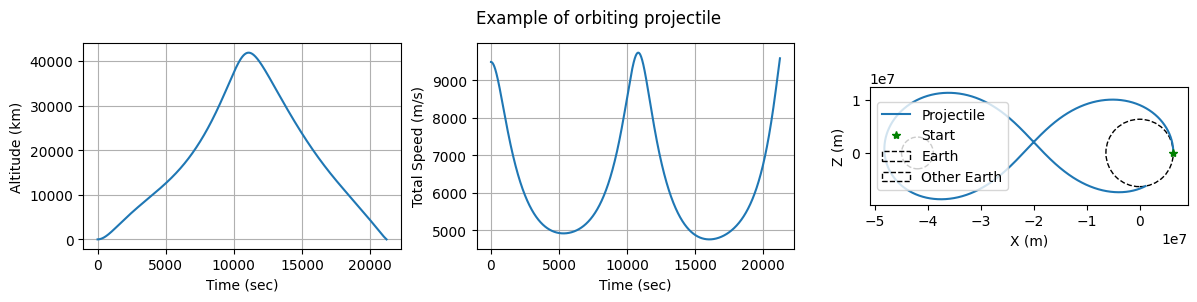

In [47]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(12, 3))
ax.flatten()

ax[0].plot(time_scale, altitude / 1000)
ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")
ax[0].grid()

ax[1].plot(time_scale, velout)
ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")
ax[1].grid()

ax[2].plot(posx, posz, label="Projectile")
ax[2].plot(posx[0], posz[0], "g*", label="Start")
ax[2].set_xlabel("X (m)")
ax[2].set_ylabel("Z (m)")
plot_2D_planet_with_points(planet = earth, ax=ax[2],)
plot_2D_planet_with_points(planet = other_earth, ax=ax[2],)


fig.suptitle("Example of orbiting projectile")
fig.tight_layout(pad=0.8)